In [21]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
import os

dataset_path = "YOLO_format"

print(os.listdir(dataset_path))

['valid', 'test', 'data.yaml', 'train', '.ipynb_checkpoints']


In [3]:
train_path = os.path.join(dataset_path, "train")

print(os.listdir(train_path))

['images', 'labels']


In [4]:
valid_path = os.path.join(dataset_path, "valid")
test_path = os.path.join(dataset_path, "test")

print("Validation:", os.listdir(valid_path))
print("Test:", os.listdir(test_path))

Validation: ['images', 'labels']
Test: ['images', 'labels']


In [5]:
for split in ["train", "valid", "test"]:
    images_path = os.path.join(dataset_path, split, "images")
    
    image_files = [
        f for f in os.listdir(images_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp"))
    ]
    
    print(split, "images:", len(image_files))

train images: 17101
valid images: 5406
test images: 2755


In [6]:
from collections import Counter

class_names = [
    "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise"
]

for split in ["train", "valid", "test"]:
    labels_path = os.path.join(dataset_path, split, "labels")
    
    counter = Counter()
    
    for file in os.listdir(labels_path):
        if file.endswith(".txt"):
            file_path = os.path.join(labels_path, file)
            
            with open(file_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    
                    if len(parts) > 0:
                        class_id = int(parts[0])
                        counter[class_id] += 1
    
    print("\n", split.upper())
    
    for class_id, name in enumerate(class_names):
        print(name, ":", counter[class_id])


 TRAIN
Anger : 2339
Contempt : 1996
Disgust : 2242
Fear : 2021
Happy : 2154
Neutral : 1616
Sad : 1914
Surprise : 2819

 VALID
Anger : 712
Contempt : 618
Disgust : 672
Fear : 622
Happy : 791
Neutral : 514
Sad : 603
Surprise : 874

 TEST
Anger : 383
Contempt : 332
Disgust : 327
Fear : 318
Happy : 399
Neutral : 250
Sad : 278
Surprise : 468


In [7]:
for split in ["train", "valid", "test"]:
    
    images_path = os.path.join(dataset_path, split, "images")
    
    widths = []
    heights = []
    
    for file in os.listdir(images_path):
        
        file_path = os.path.join(images_path, file)
        
        try:
            img = Image.open(file_path)
            width, height = img.size
            
            widths.append(width)
            heights.append(height)
            
        except:
            pass
    
    print("\n", split.upper())
    print("Number of images:", len(widths))
    print("Minimum width:", min(widths))
    print("Maximum width:", max(widths))
    print("Average width:", sum(widths) / len(widths))
    print("Minimum height:", min(heights))
    print("Maximum height:", max(heights))
    print("Average height:", sum(heights) / len(heights))


 TRAIN
Number of images: 17101
Minimum width: 96
Maximum width: 96
Average width: 96.0
Minimum height: 96
Maximum height: 96
Average height: 96.0

 VALID
Number of images: 5406
Minimum width: 96
Maximum width: 96
Average width: 96.0
Minimum height: 96
Maximum height: 96
Average height: 96.0

 TEST
Number of images: 2755
Minimum width: 96
Maximum width: 96
Average width: 96.0
Minimum height: 96
Maximum height: 96
Average height: 96.0


In [8]:
def get_blur_score(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        return None

    return cv2.Laplacian(image, cv2.CV_64F).var()


blur_results = []

for split in ["train", "valid", "test"]:

    images_path = os.path.join(dataset_path, split, "images")

    for file in os.listdir(images_path):

        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):

            file_path = os.path.join(images_path, file)

            score = get_blur_score(file_path)

            if score is not None:
                blur_results.append({
                    "split": split,
                    "filename": file,
                    "blur_score": score
                })

blur_df = pd.DataFrame(blur_results)

print("Total images analyzed:", len(blur_df))

Total images analyzed: 25262


In [9]:
blur_df["blur_score"].describe()

count    25262.000000
mean      3280.728479
std       1888.228727
min        351.926938
25%       2052.260494
50%       2829.756041
75%       3956.496756
max      43802.111115
Name: blur_score, dtype: float64

In [10]:
blur_df.groupby("split")["blur_score"].describe()

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,2755.0,3219.627399,1766.535185,674.767107,2022.629737,2792.193525,3901.707663,18421.479829
train,17101.0,3289.182173,1889.011253,351.926938,2053.544915,2830.614654,3966.273473,36395.613210
valid,5406.0,3285.124863,1944.696808,443.232807,2064.212178,2845.079613,3952.353275,43802.111115


In [11]:
blur_df["blur_score"].describe()

count    25262.000000
mean      3280.728479
std       1888.228727
min        351.926938
25%       2052.260494
50%       2829.756041
75%       3956.496756
max      43802.111115
Name: blur_score, dtype: float64

In [12]:
blur_df.sort_values("blur_score").head(20)

,split,filename,blur_score
7527,train,ffhq_3670.png,351.926938
11728,train,ffhq_4114.png,420.159489
17245,valid,image0031845.jpg,443.232807
20519,valid,ffhq_3120.png,459.334523
8782,train,ffhq_5153.png,484.401243
3339,train,ffhq_5048.png,505.942327
7504,train,ffhq_4645.png,532.696137
2786,train,ffhq_4022.png,543.590376
13101,train,ffhq_4574.png,550.070093
187,train,image0037830.jpg,562.311701


In [13]:
blur_df.sort_values("blur_score").head(20)

,split,filename,blur_score
7527,train,ffhq_3670.png,351.926938
11728,train,ffhq_4114.png,420.159489
17245,valid,image0031845.jpg,443.232807
20519,valid,ffhq_3120.png,459.334523
8782,train,ffhq_5153.png,484.401243
3339,train,ffhq_5048.png,505.942327
7504,train,ffhq_4645.png,532.696137
2786,train,ffhq_4022.png,543.590376
13101,train,ffhq_4574.png,550.070093
187,train,image0037830.jpg,562.311701


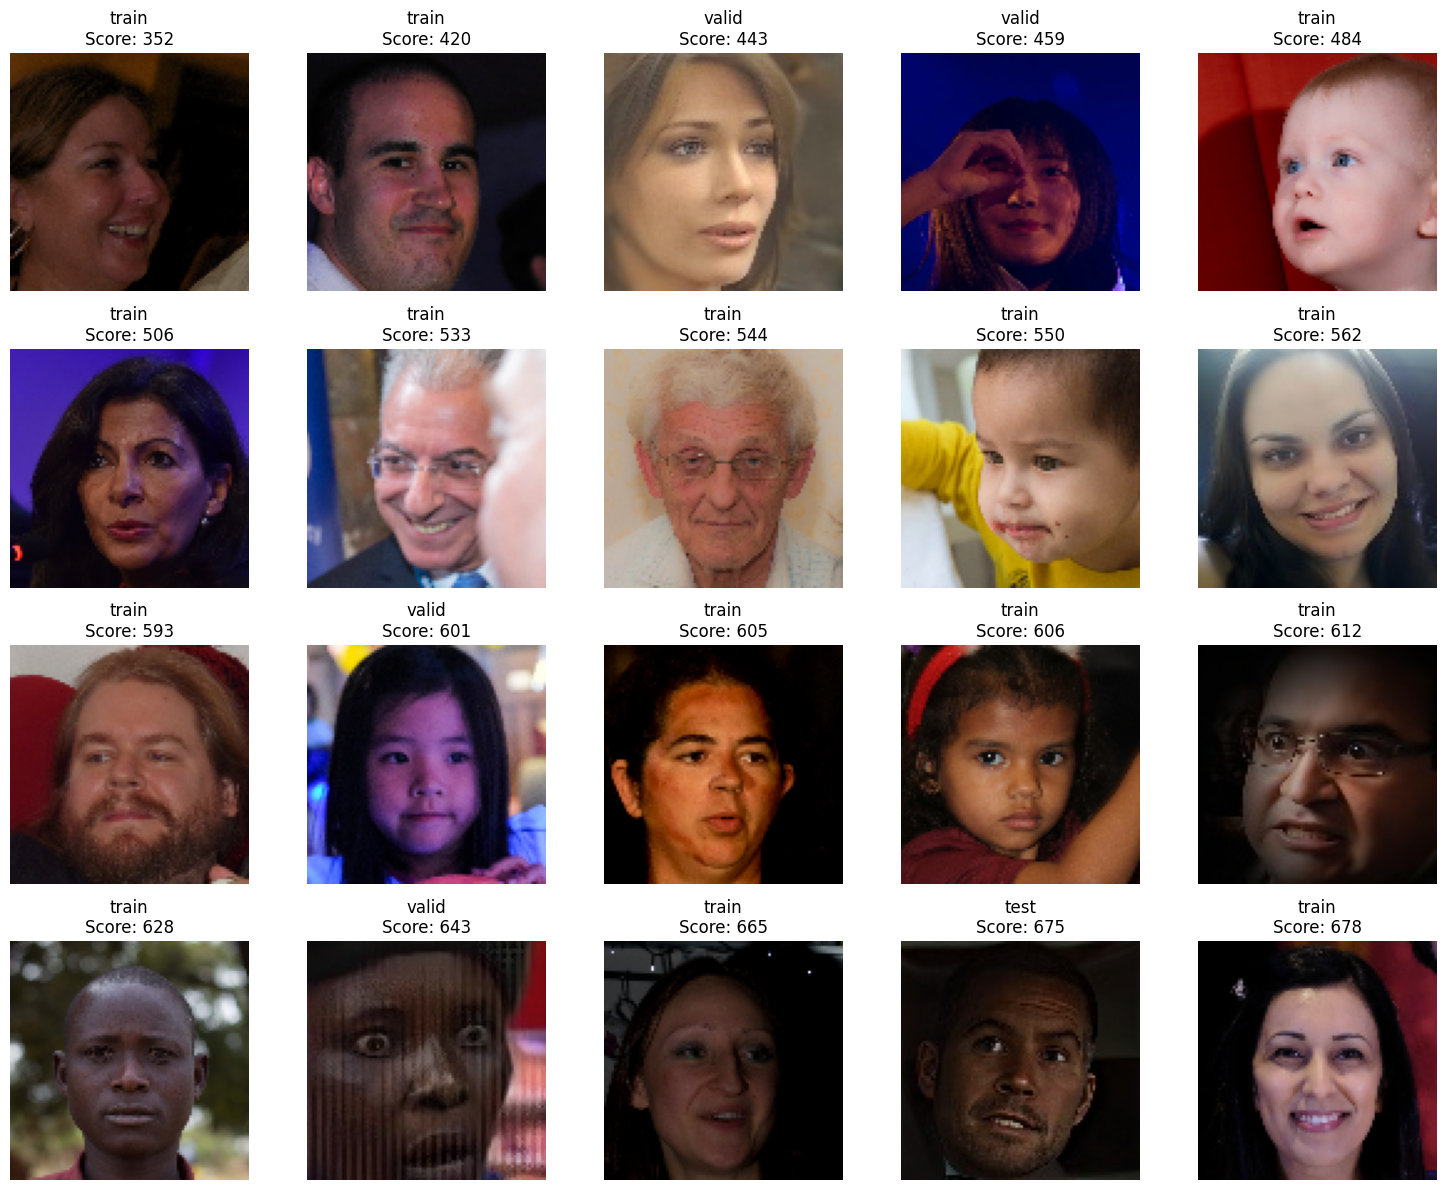

In [14]:
lowest_blur = blur_df.sort_values("blur_score").head(20)

fig, axes = plt.subplots(4, 5, figsize=(15, 12))

for ax, (_, row) in zip(axes.flat, lowest_blur.iterrows()):
    
    image_path = os.path.join(
        dataset_path,
        row["split"],
        "images",
        row["filename"]
    )
    
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    ax.imshow(image)
    ax.set_title(
        f'{row["split"]}\nScore: {row["blur_score"]:.0f}'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [15]:
# Use the bottom 5% of blur scores as "potentially blurry
threshold = blur_df["blur_score"].quantile(0.05)

print("Blur threshold:", threshold)

blur_df["potentially_blurry"] = blur_df["blur_score"] < threshold

print("\nPotentially blurry images:", blur_df["potentially_blurry"].sum())
print("Total images:", len(blur_df))
print("Percentage:", 
      blur_df["potentially_blurry"].mean() * 100)

Blur threshold: 1343.8898056195108

Potentially blurry images: 1264
Total images: 25262
Percentage: 5.003562663288734


In [16]:
blur_df.groupby("split")["potentially_blurry"].agg(["sum", "count"])

,sum,count
split,,
test,156,2755
train,853,17101
valid,255,5406


In [17]:
resolution_data = []

for split in ["train", "valid", "test"]:
    
    images_path = os.path.join(dataset_path, split, "images")
    
    for file in os.listdir(images_path):
        
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            
            file_path = os.path.join(images_path, file)
            
            try:
                img = Image.open(file_path)
                width, height = img.size
                
                resolution_data.append({
                    "split": split,
                    "filename": file,
                    "width": width,
                    "height": height,
                    "resolution": f"{width}x{height}",
                    "pixels": width * height
                })
                
            except:
                pass

resolution_df = pd.DataFrame(resolution_data)

print("Total images analyzed:", len(resolution_df))

Total images analyzed: 25262


In [18]:
resolution_df["resolution"].value_counts().head(20)

resolution
96x96    25262
Name: count, dtype: int64

In [19]:
for split in ["train", "valid", "test"]:
    print("\n", split.upper())
    print(resolution_df[
        resolution_df["split"] == split
    ]["resolution"].value_counts().head(10))


 TRAIN
resolution
96x96    17101
Name: count, dtype: int64

 VALID
resolution
96x96    5406
Name: count, dtype: int64

 TEST
resolution
96x96    2755
Name: count, dtype: int64


In [20]:
image_properties = []

for split in ["train", "valid", "test"]:
    
    images_path = os.path.join(dataset_path, split, "images")
    
    for file in os.listdir(images_path):
        
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            
            file_path = os.path.join(images_path, file)
            
            try:
                img = Image.open(file_path)
                
                image_properties.append({
                    "split": split,
                    "filename": file,
                    "mode": img.mode,
                    "format": img.format,
                    "width": img.width,
                    "height": img.height
                })
                
            except:
                pass

properties_df = pd.DataFrame(image_properties)

print(properties_df["mode"].value_counts())
print("\nFormats:")
print(properties_df["format"].value_counts())

mode
RGB    25262
Name: count, dtype: int64

Formats:
format
JPEG    17465
PNG      7797
Name: count, dtype: int64


In [22]:
brightness_data = []

for split in ["train", "valid", "test"]:
    
    images_path = os.path.join(dataset_path, split, "images")
    
    for file in os.listdir(images_path):
        
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp")):
            
            file_path = os.path.join(images_path, file)
            
            image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
            
            if image is not None:
                brightness = np.mean(image)
                
                brightness_data.append({
                    "split": split,
                    "filename": file,
                    "brightness": brightness
                })

brightness_df = pd.DataFrame(brightness_data)

print(brightness_df["brightness"].describe())

count    25262.000000
mean       117.007822
std         30.605243
min         20.152886
25%         95.960015
50%        115.504666
75%        136.805447
max        228.959635
Name: brightness, dtype: float64


In [23]:
brightness_df.groupby("split")["brightness"].mean()

split
test     116.935113
train    117.142868
valid    116.617680
Name: brightness, dtype: float64